# DSCI 552 — Homework 1
## K-Nearest Neighbors on the Vertebral Column Data Set

**Name:** Yanchen Liu

Binary task: **Normal (NO) = 0**, **Abnormal (AB) = 1**. Throughout, the positive class is AB (1).

In [1]:
import os
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier

pd.set_option("display.precision", 4)

# Class colours (blue / orange: colour-blind safe pair)
COLORS = {0: "#2a78d6", 1: "#eb6834"}
CLASS_NAMES = {0: "0 = Normal (NO)", 1: "1 = Abnormal (AB)"}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.6,
    "lines.linewidth": 2,
})

## 1(a) Download the data

The UCI archive ships a zip with a 2-class and a 3-class version of the data, each as `.dat` (values rounded to 2 decimals) and `.arff` (full precision). We use the full-precision 2-class file `column_2C_weka.arff`; rounding would only create artificial distance ties. The cell downloads the zip only if the data is not already in `../data`.

In [2]:
DATA_DIR = "../data"
URL = "https://archive.ics.uci.edu/static/public/212/vertebral+column.zip"
ARFF_PATH = os.path.join(DATA_DIR, "column_2C_weka.arff")

if not os.path.exists(ARFF_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path, _ = urllib.request.urlretrieve(URL, os.path.join(DATA_DIR, "vertebral_column.zip"))
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)

raw, _ = arff.loadarff(ARFF_PATH)
df = pd.DataFrame(raw)
# Convert labels to 0/1: Normal -> 0, Abnormal -> 1
df["class"] = df["class"].str.decode("utf-8").map({"Normal": 0, "Abnormal": 1})
FEATURES = list(df.columns[:6])

print(df.shape)
print(df["class"].value_counts().rename(index=CLASS_NAMES))
df.head()

(310, 7)
class
1 = Abnormal (AB)    210
0 = Normal (NO)      100
Name: count, dtype: int64


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.0278,22.5526,39.6091,40.4752,98.6729,-0.2544,1
1,39.0570,10.0610,25.0154,28.9960,114.4054,4.5643,1
2,68.8320,22.2185,50.0922,46.6135,105.9851,-3.5303,1
3,69.2970,24.6529,44.3112,44.6441,101.8685,11.2115,1
4,49.7129,9.6521,28.3174,40.0608,108.1687,7.9185,1


In [3]:
df[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,60.4967,17.2365,26.1479,46.4303,58.6910,72.8777,129.8340
pelvic_tilt,310.0,17.5428,10.0083,-6.5549,10.6671,16.3577,22.1204,49.4319
lumbar_lordosis_angle,310.0,51.9309,18.5541,14.0000,37.0000,49.5624,63.0000,125.7424
sacral_slope,310.0,42.9538,13.4231,13.3669,33.3471,42.4049,52.6959,121.4296
pelvic_radius,310.0,117.9207,13.3174,70.0826,110.7092,118.2682,125.4677,163.0710
degree_spondylolisthesis,310.0,26.2967,37.5590,-11.0582,1.6037,11.7679,41.2874,418.5431


## 1(b) Pre-processing and exploratory data analysis

### 1(b)i. Scatterplots of the independent variables

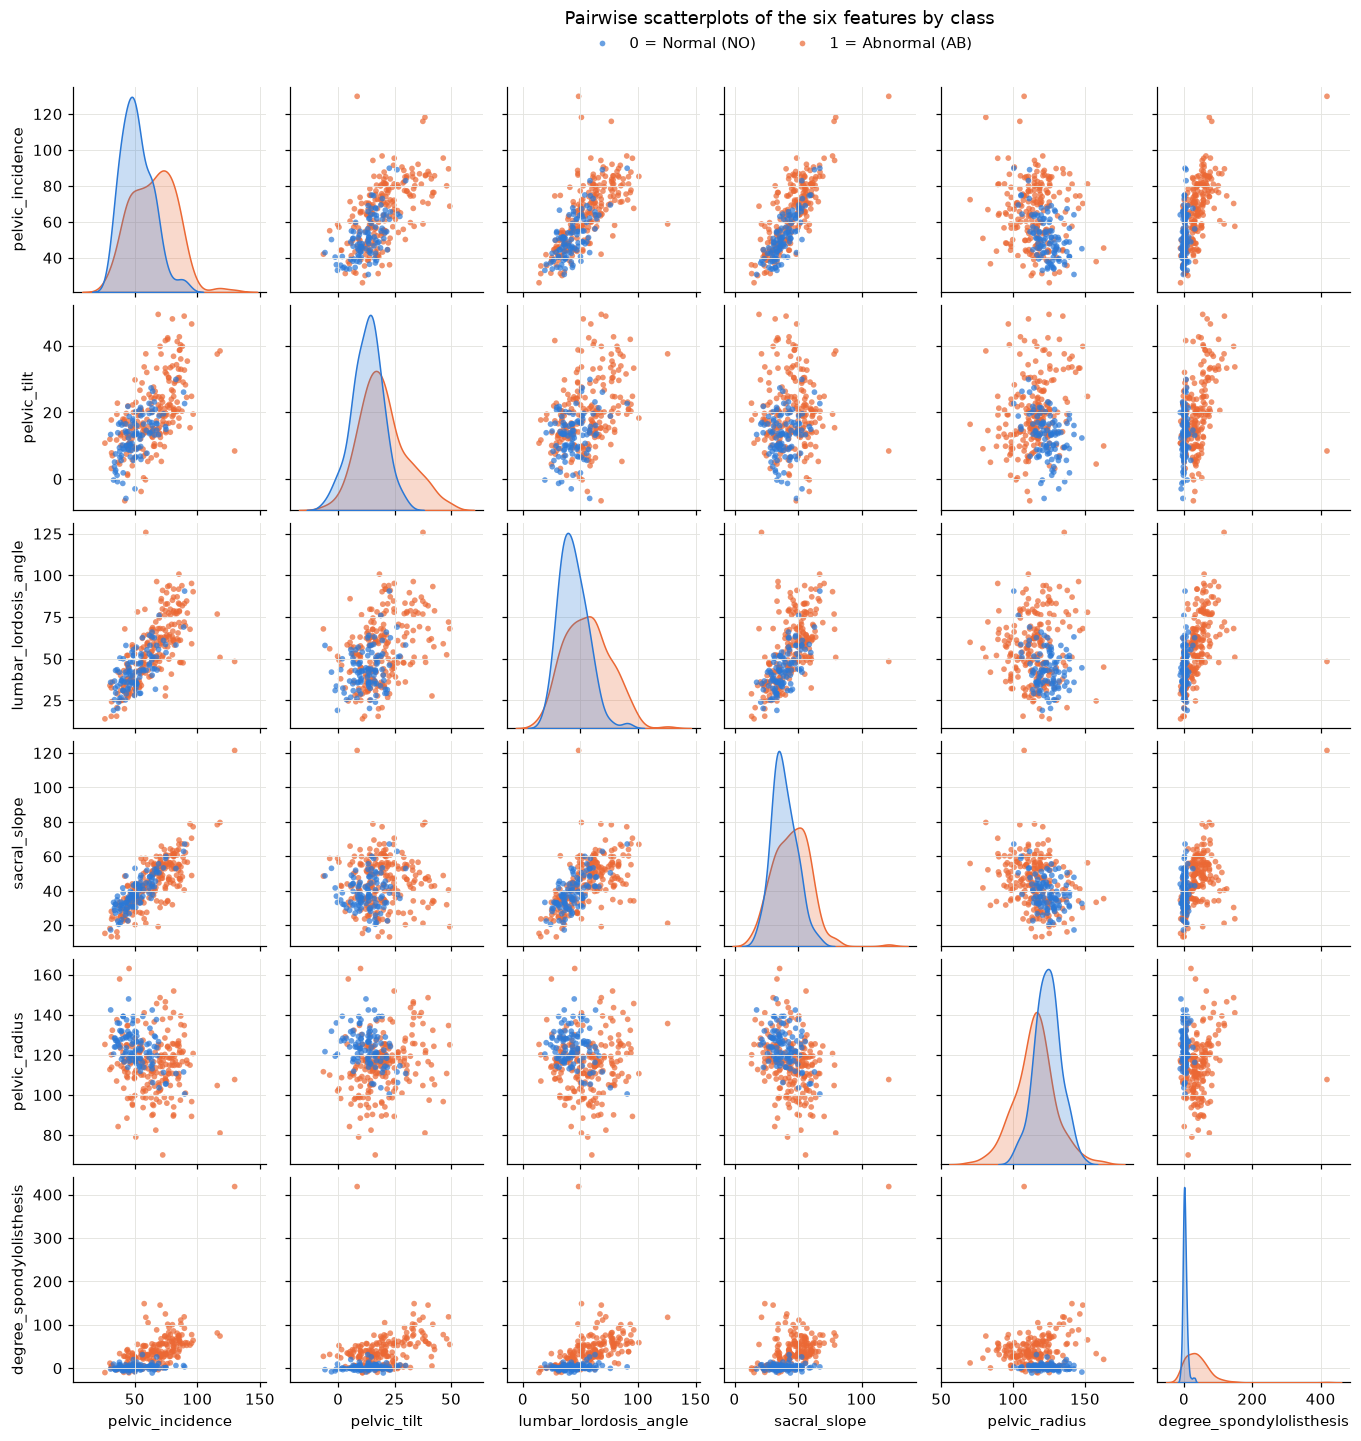

In [4]:
plot_df = df.assign(Class=df["class"].map(CLASS_NAMES))
g = sns.pairplot(
    plot_df,
    vars=FEATURES,
    hue="Class",
    hue_order=list(CLASS_NAMES.values()),
    palette={CLASS_NAMES[c]: COLORS[c] for c in COLORS},
    plot_kws={"s": 14, "alpha": 0.7, "linewidth": 0},
    diag_kws={"common_norm": False},
    height=2.1,
)
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, title=None, frameon=False)
g.figure.suptitle("Pairwise scatterplots of the six features by class", y=1.04)
plt.show()

Observations:

- **Degree of spondylolisthesis** separates the classes best: Normal patients cluster near 0, while many Abnormal patients have large positive values. There is one extreme Abnormal outlier ($\approx 418$).
- **Pelvic radius** tends to be higher for Normal patients. **Pelvic incidence**, **pelvic tilt** and **lumbar lordosis angle** tend to be higher for Abnormal patients.
- The panels for pelvic incidence vs. pelvic tilt / sacral slope are perfectly linear: geometrically, **pelvic incidence = pelvic tilt + sacral slope**. This exact collinearity matters for the Mahalanobis distance in 1(d)ii.

### 1(b)ii. Boxplots of each independent variable by class

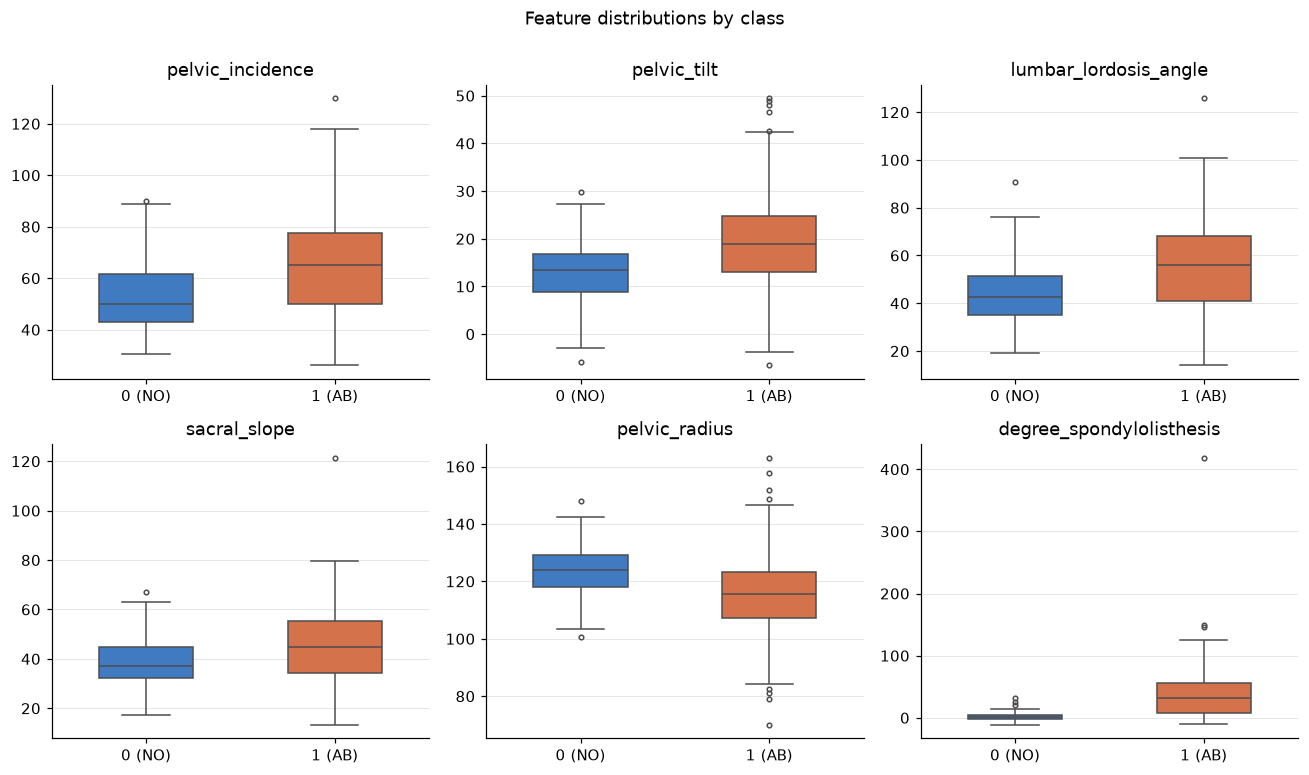

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, feature in zip(axes.ravel(), FEATURES):
    sns.boxplot(
        data=df, x="class", y=feature, hue="class", palette=COLORS,
        legend=False, width=0.5, fliersize=3, ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([0, 1], ["0 (NO)", "1 (AB)"])
fig.suptitle("Feature distributions by class", y=1.0)
fig.tight_layout()
plt.show()

The boxplots confirm the scatterplots. For degree of spondylolisthesis, the interquartile ranges of the two classes do not overlap at all (NO: $-1.5$ to 5.0; AB: 7.3 to 55.4). Pelvic incidence, pelvic tilt and lumbar lordosis angle have higher medians for AB, and pelvic radius has a lower median for AB. Sacral slope shows the most overlap between the classes.

### 1(b)iii. Train/test split

Training set: the first 70 rows of Class 0 and the first 140 rows of Class 1 (210 rows). Test set: the remaining 30 rows of Class 0 and 70 rows of Class 1 (100 rows).

In [6]:
normal_idx = df.index[df["class"] == 0]
abnormal_idx = df.index[df["class"] == 1]
train_idx = normal_idx[:70].append(abnormal_idx[:140])
test_idx = df.index.difference(train_idx)

train, test = df.loc[train_idx], df.loc[test_idx]
X_train, y_train = train[FEATURES].to_numpy(), train["class"].to_numpy()
X_test, y_test = test[FEATURES].to_numpy(), test["class"].to_numpy()

pd.DataFrame({
    "train": train["class"].value_counts().sort_index(),
    "test": test["class"].value_counts().sort_index(),
}).rename(index=CLASS_NAMES)

,train,test
class,,
0 = Normal (NO),70,30
1 = Abnormal (AB),140,70


## 1(c) Classification using KNN

### 1(c)i. KNN with the Euclidean metric

We use `sklearn.neighbors.KNeighborsClassifier` with brute-force neighbour search. Following the assignment, the features are used on their original scale (no standardisation). With an even $k$ the majority vote can tie; scikit-learn then predicts the smaller label (0).

Two helpers are reused for the rest of the homework:

- `evaluate` fits one model and returns its training and test error. It also returns the test **Brier score**, the mean of $(\hat p_i - y_i)^2$ where $\hat p_i$ is the (weighted) fraction of neighbours voting AB.
- `pick_best` returns the $k$ with the lowest test error. With 100 test points the error moves in steps of 0.01, so several $k$ can tie. In that case we keep the $k$ with the lower Brier score, i.e. the one whose votes are most confidently correct.

In [7]:
def evaluate(k, X_tr=X_train, y_tr=y_train, weights="uniform", **metric_kw):
    # Fit k-NN on (X_tr, y_tr); return train/test error and test Brier score
    model = KNeighborsClassifier(n_neighbors=k, weights=weights, algorithm="brute", **metric_kw)
    model.fit(X_tr, y_tr)
    p_test = model.predict_proba(X_test)[:, 1]
    return {
        "k": k,
        "train_error": np.mean(model.predict(X_tr) != y_tr),
        "test_error": np.mean(model.predict(X_test) != y_test),
        "test_brier": np.mean((p_test - y_test) ** 2),
    }


def sweep_k(ks, **kw):
    return pd.DataFrame([evaluate(int(k), **kw) for k in ks])


def pick_best(results):
    # Lowest test error; ties broken by the lower test Brier score
    return results.sort_values(["test_error", "test_brier"], kind="stable").iloc[0]

### 1(c)ii. Train and test error vs. $k$, for $k \in \{208, 205, \dots, 4, 1\}$

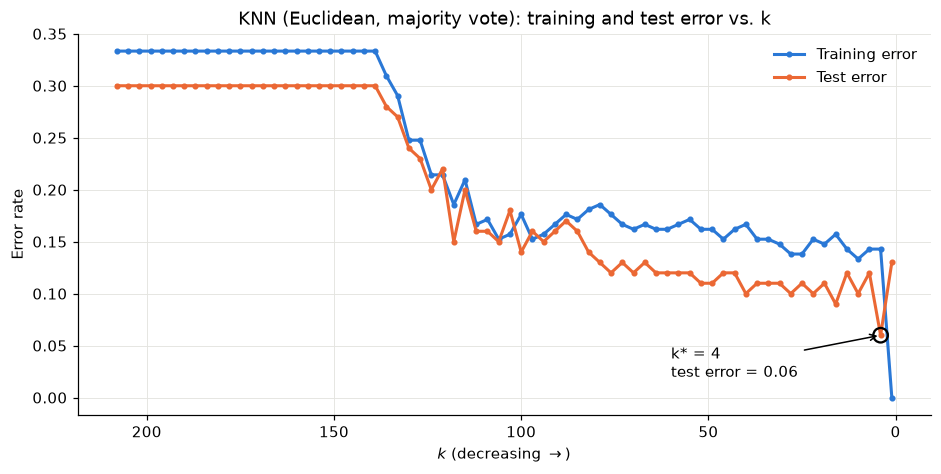

,k,train_error,test_error,test_brier
68,4,0.1429,0.06,0.0606
64,16,0.1571,0.09,0.0738
62,22,0.1524,0.10,0.0779
66,10,0.1333,0.10,0.0803
60,28,0.1381,0.10,0.0805
56,40,0.1667,0.10,0.0839
63,19,0.1476,0.11,0.0778
61,25,0.1381,0.11,0.0792


In [8]:
ks_c = np.arange(208, 0, -3)
euclid = sweep_k(ks_c, metric="euclidean")
best_euclid = pick_best(euclid)
k_star = int(best_euclid.k)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(euclid.k, euclid.train_error, color=COLORS[0], marker="o", markersize=3, label="Training error")
ax.plot(euclid.k, euclid.test_error, color=COLORS[1], marker="o", markersize=3, label="Test error")
ax.scatter([k_star], [best_euclid.test_error], s=90, facecolors="none", edgecolors="black", linewidths=1.5, zorder=5)
ax.annotate(f"k* = {k_star}\ntest error = {best_euclid.test_error:.2f}",
            xy=(k_star, best_euclid.test_error), xytext=(60, 0.02),
            arrowprops={"arrowstyle": "->", "color": "black"})
ax.invert_xaxis()   # k decreases to the right = model becomes more flexible
ax.set_xlabel(r"$k$ (decreasing $\rightarrow$)")
ax.set_ylabel("Error rate")
ax.set_title("KNN (Euclidean, majority vote): training and test error vs. k")
ax.legend(frameon=False)
plt.show()

euclid.sort_values(["test_error", "test_brier"]).head(8)

In [9]:
print(f"k* = {k_star}, training error = {best_euclid.train_error:.4f}, test error = {best_euclid.test_error:.4f}")

model = KNeighborsClassifier(n_neighbors=k_star, metric="euclidean", algorithm="brute").fit(X_train, y_train)
y_pred = model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

cm = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual 0 (NO)", "Actual 1 (AB)"],
    columns=["Predicted 0 (NO)", "Predicted 1 (AB)"],
)
display(cm)

pd.Series({
    "TPR (recall) = TP/(TP+FN)": tp / (tp + fn),
    "TNR (specificity) = TN/(TN+FP)": tn / (tn + fp),
    "Precision = TP/(TP+FP)": tp / (tp + fp),
    "F1 = 2PR/(P+R)": f1_score(y_test, y_pred),
}, name=f"k* = {k_star}").to_frame()

k* = 4, training error = 0.1429, test error = 0.0600


,Predicted 0 (NO),Predicted 1 (AB)
Actual 0 (NO),25,5
Actual 1 (AB),1,69


,k* = 4
TPR (recall) = TP/(TP+FN),0.9857
TNR (specificity) = TN/(TN+FP),0.8333
Precision = TP/(TP+FP),0.9324
F1 = 2PR/(P+R),0.9583


**Answer.** The most suitable value is **k\* = 4**, which gives the lowest test error, **0.06** (6 of 100 test points misclassified). Five errors are Normal patients predicted as Abnormal (false positives) and one is an Abnormal patient predicted as Normal (false negative).

| Metric | Value |
|------------------------------------|------------------|
| Confusion matrix (rows: actual 0/1, cols: predicted 0/1) | [[25, 5], [1, 69]] |
| True positive rate | 0.9857 |
| True negative rate | 0.8333 |
| Precision | 0.9324 |
| F1-score | 0.9583 |

The curves show the usual bias–variance pattern. For $k \gtrsim 140$, the classifier predicts AB for every point: training error 70/210 = 0.33, test error 0.30. As $k$ decreases, the model becomes more flexible and the training error falls to 0 at $k = 1$. The test error reaches its minimum at $k = 4$ and rises again to 0.13 at $k = 1$ (overfitting).

### 1(c)iii. Learning curve

For each $N \in \{10, 20, \dots, 210\}$, the training set is the first $\lfloor N/3 \rfloor$ Class-0 rows and the first $N - \lfloor N/3 \rfloor$ Class-1 rows of the training set from 1(b)iii. The best $k$ is chosen from $\{1, 6, 11, \dots\}$ with $k < N$. The test set is always the full 100-row test set.

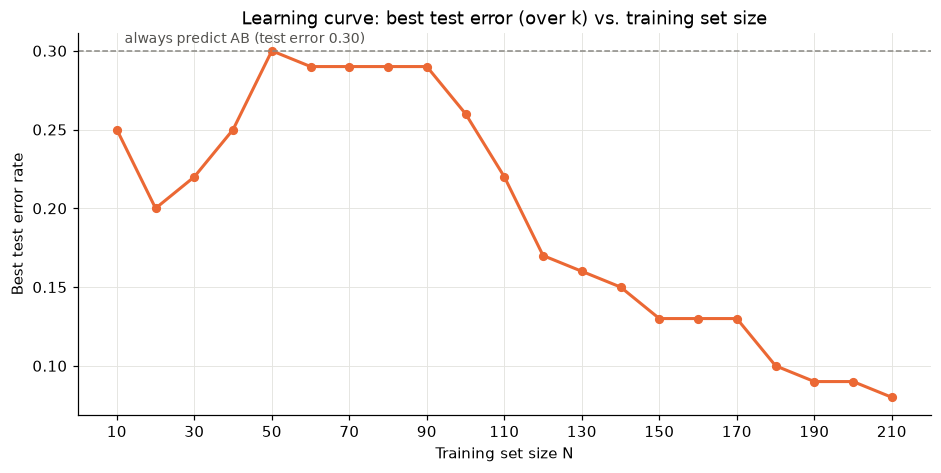

,best_k,best_test_error
N,,
10,1,0.25
20,6,0.20
30,1,0.22
40,11,0.25
50,46,0.30
60,21,0.29
70,31,0.29
80,36,0.29
90,46,0.29


In [10]:
X_train_0, X_train_1 = X_train[y_train == 0], X_train[y_train == 1]

lc_rows = []
for N in range(10, 211, 10):
    n0 = N // 3
    X_sub = np.vstack([X_train_0[:n0], X_train_1[:N - n0]])
    y_sub = np.r_[np.zeros(n0, dtype=int), np.ones(N - n0, dtype=int)]
    best = pick_best(sweep_k(range(1, N, 5), X_tr=X_sub, y_tr=y_sub, metric="euclidean"))
    lc_rows.append({"N": N, "best_k": int(best.k), "best_test_error": best.test_error})
learning_curve = pd.DataFrame(lc_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(learning_curve.N, learning_curve.best_test_error, color=COLORS[1], marker="o", markersize=5)
ax.axhline(0.30, color="#8a8984", linestyle="--", linewidth=1)
ax.text(12, 0.305, "always predict AB (test error 0.30)", color="#52514e", fontsize=9)
ax.set_xlabel("Training set size N")
ax.set_ylabel("Best test error rate")
ax.set_title("Learning curve: best test error (over k) vs. training set size")
ax.set_xticks(range(10, 211, 20))
plt.show()

learning_curve.set_index("N")

With more training data, the best test error generally falls: 0.25 at $N = 10$ and **0.08 at $N = 210$**. At $N = 210$, $k = 6$ is best because $k = 4$ is not in the grid $\{1, 6, 11, \dots\}$.

The curve is not monotone. It rises to about 0.29–0.30 for $N = 50$–$90$, which is no better than always predicting AB. The row order explains this. The 3-class version of the data shows that the Abnormal rows are sorted by diagnosis: the first 60 are Disk Hernia and the remaining 150 are Spondylolisthesis. So for $N \le 90$ the Class-1 training rows are all Disk Hernia patients, while every Abnormal test patient has Spondylolisthesis. Once $N \ge 100$, Spondylolisthesis patients enter the training set and the error drops quickly.

## 1(d) Other distance metrics

All models below use the full training set and $k \in \{1, 6, 11, \dots, 196\}$.

The Minkowski distance is $d_p(x, y) = \left(\sum_j |x_j - y_j|^p\right)^{1/p}$. It gives the Manhattan distance for $p = 1$, the Euclidean distance for $p = 2$, and the Chebyshev distance $\max_j |x_j - y_j|$ as $p \to \infty$.

### 1(d)iA. Manhattan distance (p = 1)

In [11]:
K_GRID = range(1, 197, 5)

manhattan = sweep_k(K_GRID, metric="minkowski", p=1)
best_manhattan = pick_best(manhattan)
k_manhattan = int(best_manhattan.k)
print(f"Manhattan: k* = {k_manhattan}, test error = {best_manhattan.test_error:.2f}")
manhattan.sort_values(["test_error", "test_brier"]).head(6)

Manhattan: k* = 6, test error = 0.11


,k,train_error,test_error,test_brier
1,6,0.1381,0.11,0.0792
2,11,0.1429,0.11,0.0816
5,26,0.1667,0.11,0.0887
0,1,0.0000,0.11,0.1100
4,21,0.1476,0.12,0.0814
3,16,0.1333,0.12,0.0857


Four values tie at the lowest test error of 0.11: $k = 1, 6, 11, 26$. The Brier-score tie-break selects **k\* = 6**. The alternatives would be poor choices anyway: $k = 1$ only memorises the training set (training error 0), and $k = 11$ and $k = 26$ have higher Brier scores.

### 1(d)iB. Minkowski distance with $\log_{10}(p) \in \{0.1, 0.2, \dots, 1.0\}$, using $k = k^*$ from Manhattan

In [12]:
log10_ps = np.round(np.arange(0.1, 1.01, 0.1), 1)
minkowski = pd.DataFrame([
    {"log10_p": lp, "p": 10 ** lp, **evaluate(k_manhattan, metric="minkowski", p=10 ** lp)}
    for lp in log10_ps
])
best_minkowski = pick_best(minkowski)
print(f"Best log10(p) = {best_minkowski.log10_p:.1f} (p = {best_minkowski.p:.3f}), "
      f"test error = {best_minkowski.test_error:.2f} at k = {k_manhattan}")
minkowski

Best log10(p) = 0.6 (p = 3.981), test error = 0.06 at k = 6


,log10_p,p,k,train_error,test_error,test_brier
0,0.1,1.2589,6,0.1381,0.09,0.0700
1,0.2,1.5849,6,0.1476,0.09,0.0672
2,0.3,1.9953,6,0.1476,0.08,0.0667
3,0.4,2.5119,6,0.1524,0.08,0.0683
4,0.5,3.1623,6,0.1476,0.08,0.0697
5,0.6,3.9811,6,0.1524,0.06,0.0686
6,0.7,5.0119,6,0.1524,0.07,0.0703
7,0.8,6.3096,6,0.1476,0.08,0.0700
8,0.9,7.9433,6,0.1476,0.09,0.0719
9,1.0,10.0000,6,0.1333,0.09,0.0739


**Answer: the best value is $\log_{10}(p) = 0.6$**, i.e. $p = 10^{0.6} \approx 3.98$, with test error **0.06** at $k = 6$.

Sensitivity check: this answer depends on the $k$ carried over from 1(d)iA. The table below repeats the sweep for every $k$ that tied for Manhattan.

In [13]:
pd.DataFrame(
    {k: [evaluate(k, metric="minkowski", p=10 ** lp)["test_error"] for lp in log10_ps] for k in [1, 6, 11, 26]},
    index=pd.Index(log10_ps, name="log10(p)"),
).rename(columns=lambda k: f"test error, k={k}")

,"test error, k=1","test error, k=6","test error, k=11","test error, k=26"
log10(p),,,,
0.1,0.13,0.09,0.11,0.10
0.2,0.13,0.09,0.11,0.10
0.3,0.13,0.08,0.12,0.11
0.4,0.14,0.08,0.12,0.10
0.5,0.14,0.08,0.12,0.11
0.6,0.12,0.06,0.12,0.10
0.7,0.11,0.07,0.12,0.11
0.8,0.11,0.08,0.11,0.11
0.9,0.11,0.09,0.11,0.11


### 1(d)iC. Chebyshev distance ($p \to \infty$)

In [14]:
chebyshev = sweep_k(K_GRID, metric="chebyshev")
best_chebyshev = pick_best(chebyshev)
print(f"Chebyshev: k* = {int(best_chebyshev.k)}, test error = {best_chebyshev.test_error:.2f}")
chebyshev.sort_values(["test_error", "test_brier"]).head(5)

Chebyshev: k* = 16, test error = 0.08


,k,train_error,test_error,test_brier
3,16,0.1476,0.08,0.0729
1,6,0.1524,0.10,0.0728
7,36,0.1524,0.10,0.0793
4,21,0.1333,0.11,0.0796
15,76,0.1762,0.11,0.1008


### 1(d)ii. Mahalanobis distance

$d_M(x, y) = \sqrt{(x - y)^\top \Sigma^{-1} (x - y)}$, where $\Sigma$ is the covariance matrix of the training features.

Because pelvic incidence equals pelvic tilt plus sacral slope for every patient, $\Sigma$ is singular. Its smallest eigenvalue is about $10^{-13}$, which is numerical noise from the data being stored to 8 decimals. Using `inv` would amplify that noise without bound. As footnote 6 suggests, we use the **pseudoinverse** $\Sigma^{+}$. The cutoff `rcond=1e-10` treats the noise-level eigenvalue as exactly 0.

In [15]:
cov = np.cov(X_train, rowvar=False)
print("Eigenvalues of the training covariance:", np.array2string(np.linalg.eigvalsh(cov), precision=4))
print("max |PI - (PT + SS)| over all patients:",
      np.abs(df.pelvic_incidence - df.pelvic_tilt - df.sacral_slope).max())

VI = np.linalg.pinv(cov, rcond=1e-10, hermitian=True)

# Check: pseudoinverse == ordinary inverse on the reduced feature set (drop pelvic_incidence)
keep = [f != "pelvic_incidence" for f in FEATURES]
VI_reduced = np.linalg.inv(np.cov(X_train[:, keep], rowvar=False))
max_diff = np.abs(
    cdist(X_test, X_train, "mahalanobis", VI=VI)
    - cdist(X_test[:, keep], X_train[:, keep], "mahalanobis", VI=VI_reduced)
).max()
print(f"max |d_pinv - d_reduced| over all test-train pairs: {max_diff:.2e}")

Eigenvalues of the training covariance: [8.5513e-14 6.4928e+01 9.7784e+01 1.4696e+02 3.3937e+02 1.8907e+03]
max |PI - (PT + SS)| over all patients: 1.0000007932831068e-08
max |d_pinv - d_reduced| over all test-train pairs: 1.45e-09


In [16]:
mahalanobis = sweep_k(K_GRID, metric="mahalanobis", metric_params={"VI": VI})
best_mahalanobis = pick_best(mahalanobis)
print(f"Mahalanobis: k* = {int(best_mahalanobis.k)}, test error = {best_mahalanobis.test_error:.2f}")
mahalanobis.sort_values(["test_error", "test_brier"]).head(5)

Mahalanobis: k* = 1, test error = 0.15


,k,train_error,test_error,test_brier
0,1,0.0000,0.15,0.1500
1,6,0.1381,0.16,0.1153
3,16,0.1524,0.17,0.1180
5,26,0.1619,0.17,0.1217
2,11,0.1571,0.18,0.1155


The pseudoinverse distance matches the reduced-feature distance to numerical precision. The two approaches are therefore equivalent, as footnote 6 says.

### 1(d) Summary table

In [17]:
euclid_same_grid = pick_best(sweep_k(K_GRID, metric="euclidean"))

summary_d = pd.DataFrame([
    {"metric": "Euclidean (reference)", "parameter": "p = 2", **euclid_same_grid},
    {"metric": "i.A Manhattan", "parameter": "p = 1", **best_manhattan},
    {"metric": "i.B Minkowski", "parameter": f"log10(p) = {best_minkowski.log10_p:.1f}", **best_minkowski},
    {"metric": "i.C Chebyshev", "parameter": "p = inf", **best_chebyshev},
    {"metric": "ii  Mahalanobis", "parameter": "pinv(cov)", **best_mahalanobis},
]).astype({"k": int}).rename(columns={"k": "k*"})
summary_d.set_index("metric")[["parameter", "k*", "train_error", "test_error"]]

,parameter,k*,train_error,test_error
metric,,,,
Euclidean (reference),p = 2,6,0.1476,0.08
i.A Manhattan,p = 1,6,0.1381,0.11
i.B Minkowski,log10(p) = 0.6,6,0.1524,0.06
i.C Chebyshev,p = inf,16,0.1476,0.08
ii Mahalanobis,pinv(cov),1,0.0000,0.15


The best metric overall is Minkowski with $\log_{10}(p) = 0.6$ at $k = 6$ (test error 0.06). Chebyshev comes next at 0.08, tied with Euclidean on the same $k$ grid, then Manhattan at 0.11. Mahalanobis is clearly worst at 0.15, with best $k = 1$. A likely reason is that it rescales every direction of variation to unit variance. Low-variance directions that carry little class information then count as much as the high-variance, informative ones such as degree of spondylolisthesis.

## 1(e) Weighted voting

Each neighbour's vote is weighted by $1/d$, where $d$ is its distance to the query point (`weights="distance"`); $k \in \{1, 6, 11, \dots, 196\}$.

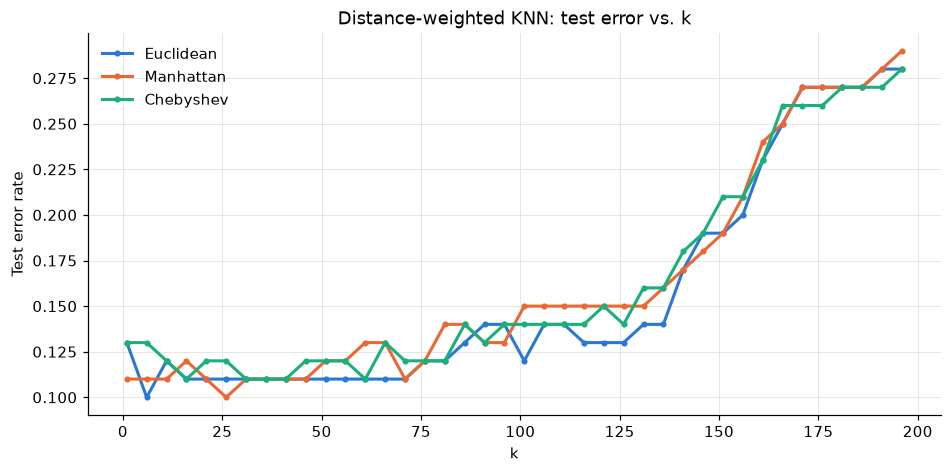

,k*,train_error,test_error
metric,,,
Euclidean,6,0.0,0.10
Manhattan,26,0.0,0.10
Chebyshev,16,0.0,0.11


In [18]:
weighted = {
    name: sweep_k(K_GRID, metric=name, weights="distance")
    for name in ["euclidean", "manhattan", "chebyshev"]
}

fig, ax = plt.subplots(figsize=(10, 4.5))
for (name, res), color in zip(weighted.items(), ["#2a78d6", "#eb6834", "#1baf7a"]):
    ax.plot(res.k, res.test_error, color=color, marker="o", markersize=3, label=name.capitalize())
ax.set_xlabel("k")
ax.set_ylabel("Test error rate")
ax.set_title("Distance-weighted KNN: test error vs. k")
ax.legend(frameon=False)
plt.show()

summary_e = pd.DataFrame([
    {"metric": name.capitalize(), **pick_best(res)[["k", "train_error", "test_error"]].to_dict()}
    for name, res in weighted.items()
]).astype({"k": int}).rename(columns={"k": "k*"}).set_index("metric")
summary_e

In [19]:
# All k values that reach each metric's best test error
{name.capitalize(): res.k[res.test_error == res.test_error.min()].tolist() for name, res in weighted.items()}

{'Euclidean': [6], 'Manhattan': [26], 'Chebyshev': [16, 31, 36, 41, 61]}

**Answer (best test errors with weighted voting):**

| Metric | Best test error | Selected k\* |
|---|---|---|
| Euclidean | 0.10 | 6 |
| Manhattan | 0.10 | 26 |
| Chebyshev | 0.11 | 16 (ties with k = 31, 36, 41, 61) |

On the same $k$ grid, weighted voting helps Manhattan slightly (0.10 vs. 0.11 with majority voting). It is worse for Euclidean (0.10 vs. 0.08) and Chebyshev (0.11 vs. 0.08).

## 1(f) Lowest training error rate

In [20]:
all_runs = {
    "Euclidean, majority (1(c)ii grid)": euclid,
    "Manhattan, majority": manhattan,
    "Chebyshev, majority": chebyshev,
    "Mahalanobis, majority": mahalanobis,
    **{f"{name.capitalize()}, weighted": res for name, res in weighted.items()},
}


def k_attaining(res, err):
    ks = res.k[res.train_error == err].tolist()
    return "all k" if len(ks) == len(res) else ks


pd.DataFrame([
    {"run": name, "min training error": res.train_error.min(),
     "k attaining it": k_attaining(res, res.train_error.min())}
    for name, res in all_runs.items()
]).set_index("run")

,min training error,k attaining it
run,,
"Euclidean, majority (1(c)ii grid)",0.0,[1]
"Manhattan, majority",0.0,[1]
"Chebyshev, majority",0.0,[1]
"Mahalanobis, majority",0.0,[1]
"Euclidean, weighted",0.0,all k
"Manhattan, weighted",0.0,all k
"Chebyshev, weighted",0.0,all k


In [21]:
# Lowest training error among the non-trivial models (majority vote, k > 1)
majority = pd.concat([res.assign(run=name) for name, res in all_runs.items() if "majority" in name])
majority[majority.k > 1].nsmallest(1, "train_error", keep="all")[["run", "k", "train_error", "test_error"]]

,run,k,train_error,test_error
66,"Euclidean, majority (1(c)ii grid)",10,0.1333,0.10
3,"Manhattan, majority",16,0.1333,0.12
4,"Chebyshev, majority",21,0.1333,0.11


**Answer: the lowest training error rate is 0.** Two kinds of model reach it:

- **$k = 1$ with any metric.** Each training point is its own nearest neighbour at distance 0, and there are no duplicate points with conflicting labels.
- **Distance-weighted voting, for every $k$.** The query point itself is in the training set at distance 0. It therefore gets all the weight and decides its own label.

A training error of 0 says nothing about generalisation: the 1-NN models have test errors of 0.11 to 0.15. Among the non-trivial models (majority vote, $k > 1$), the lowest training error is 0.1333, reached by Euclidean ($k = 10$), Manhattan ($k = 16$) and Chebyshev ($k = 21$).

## Summary of answers

| Part | Result |
|--------|--------------------------------------------------------------|
| 1(c)ii | k\* = 4 (Euclidean): test error 0.06; confusion matrix [[25, 5], [1, 69]]; TPR 0.986, TNR 0.833, precision 0.932, F1 0.958 |
| 1(c)iii | Best test error falls from 0.25 (N = 10) to 0.08 (N = 210). It is not monotone because of the Disk Hernia / Spondylolisthesis row ordering |
| 1(d)iA | Manhattan: k\* = 6, test error 0.11 |
| 1(d)iB | Best $\log_{10}(p) = 0.6$ ($p \approx 3.98$): test error 0.06 at k = 6 |
| 1(d)iC | Chebyshev: k\* = 16, test error 0.08 |
| 1(d)ii | Mahalanobis (pseudoinverse): k\* = 1, test error 0.15 |
| 1(e) | Weighted voting: Euclidean 0.10 (k = 6), Manhattan 0.10 (k = 26), Chebyshev 0.11 (k = 16) |
| 1(f) | Lowest training error = 0 (k = 1, or any distance-weighted model) |